#  Flight Delay Analysis 2022 — Complete PySpark Pipeline


## 1. Imports & Spark Session

In [3]:
# Core PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, desc, when, floor, count, isnan, isnull, round as spark_round
)

# ML — Feature Engineering
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler, PCA
)

# ML — Supervised Models
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
)

# ML — Unsupervised
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# ML — Evaluation (supervised)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)

# ML — Tuning
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Neural Network (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler as SkScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Python standard
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [4]:
spark = (
    SparkSession.builder
    .appName("FlightDelayAnalysis_2022")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.1.1


## 2. Data Loading & Schema Inspection

In [6]:
# ── Update this path to match your environment ──────────────────────────────
FILE_PATH = r"D:\projects\datasets\Combined_Flights_2022.csv"
# ────────────────────────────────────────────────────────────────────────────

df = spark.read.csv(FILE_PATH, header=True, inferSchema=True)

print(f"Rows    : {df.count():,}")
print(f"Columns : {len(df.columns)}")
df.printSchema()

Rows    : 4,078,318
Columns : 61
root
 |-- FlightDate: date (nullable = true)
 |-- Airline: string (nullable = true)
 |-- Origin: string (nullable = true)
 |-- Dest: string (nullable = true)
 |-- Cancelled: boolean (nullable = true)
 |-- Diverted: boolean (nullable = true)
 |-- CRSDepTime: integer (nullable = true)
 |-- DepTime: double (nullable = true)
 |-- DepDelayMinutes: double (nullable = true)
 |-- DepDelay: double (nullable = true)
 |-- ArrTime: double (nullable = true)
 |-- ArrDelayMinutes: double (nullable = true)
 |-- AirTime: double (nullable = true)
 |-- CRSElapsedTime: double (nullable = true)
 |-- ActualElapsedTime: double (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DayofMonth: integer (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Marketing_Airline_Network: string (nullable = true)
 |-- Operated_or_Branded_Code_Share_Part

In [7]:
df.show(5, truncate=True)

+----------+--------------------+------+----+---------+--------+----------+-------+---------------+--------+-------+---------------+-------+--------------+-----------------+--------+----+-------+-----+----------+---------+-------------------------+---------------------------------------+------------------------+---------------------------+-------------------------------+-----------------+------------------------+---------------------------+-----------+-------------------------------+---------------+------------------+------------------+--------------------+-----------+---------------+---------------+---------+-------------+----------------+----------------+-------------------+---------+-------------+-------------+-------+--------+--------------------+----------+-------+---------+--------+------+----------+--------+--------+------------------+----------+-------------+------------------+
|FlightDate|             Airline|Origin|Dest|Cancelled|Diverted|CRSDepTime|DepTime|DepDelayMinutes|De

## 3. Data Cleaning

- Remove cancelled & diverted flights (no meaningful arrival delay).
- Drop nulls only on columns required for EDA and modelling — avoids over-dropping.
- Drop duplicate rows.

In [9]:
# Null count for columns that matter most
key_cols = ["ArrDelayMinutes", "DepDelayMinutes", "AirTime", "Distance",
            "Airline", "Origin", "Dest", "DayOfWeek", "OriginState"]

# Separate numeric and string columns
numeric_cols = ["ArrDelayMinutes", "DepDelayMinutes", "AirTime", "Distance"]
string_cols = ["Airline", "Origin", "Dest", "DayOfWeek", "OriginState"]

null_counts = df.select(
    [count(when(isnull(c) | isnan(c), c)).alias(c) for c in numeric_cols] +
    [count(when(isnull(c), c)).alias(c) for c in string_cols]
)
null_counts.show()

+---------------+---------------+-------+--------+-------+------+----+---------+-----------+
|ArrDelayMinutes|DepDelayMinutes|AirTime|Distance|Airline|Origin|Dest|DayOfWeek|OriginState|
+---------------+---------------+-------+--------+-------+------+----+---------+-----------+
|         133402|         120495| 133402|       0|      0|     0|   0|        0|          0|
+---------------+---------------+-------+--------+-------+------+----+---------+-----------+



In [10]:
# Step 1 – Remove cancelled / diverted flights
df_clean = df.filter(
    (col("Cancelled") == False) & (col("Diverted") == False)
)

# Step 2 – Drop nulls only on required columns
required_cols = [
    "ArrDelayMinutes", "DepDelayMinutes", "AirTime",
    "Distance", "Airline", "Origin", "Dest",
    "DayOfWeek", "OriginState", "Month", "CRSDepTime"
]
df_clean = df_clean.dropna(subset=required_cols)

# Step 3 – Drop exact duplicate rows
df_clean = df_clean.dropDuplicates()

print(f"Clean rows  : {df_clean.count():,}")
print(f"Columns kept: {len(df_clean.columns)}")

Clean rows  : 3,944,916
Columns kept: 61


## 4. Exploratory Data Analysis (EDA)

In [12]:
# Summary statistics for key numeric columns
df_clean.select(
    "ArrDelayMinutes", "DepDelayMinutes", "AirTime", "Distance"
).describe().show()

+-------+------------------+------------------+------------------+-----------------+
|summary|   ArrDelayMinutes|   DepDelayMinutes|           AirTime|         Distance|
+-------+------------------+------------------+------------------+-----------------+
|  count|           3944916|           3944916|           3944916|          3944916|
|   mean|15.783071426615928|15.940134086505264|111.00754870319165|798.8928636249796|
| stddev| 51.98423581313942| 52.16239928825925| 69.96245895307058|593.1635201368059|
|    min|               0.0|               0.0|               8.0|             31.0|
|    max|            7232.0|            7223.0|             727.0|           5095.0|
+-------+------------------+------------------+------------------+-----------------+



In [13]:
# Top 10 busiest origin airports
print("=== Top 10 Busiest Origin Airports ===")
df_clean.groupBy("Origin") \
    .count() \
    .orderBy(desc("count")) \
    .show(10)

=== Top 10 Busiest Origin Airports ===
+------+------+
|Origin| count|
+------+------+
|   ATL|179852|
|   ORD|166191|
|   DFW|155128|
|   DEN|153283|
|   CLT|121549|
|   LAX|109752|
|   SEA| 96705|
|   LAS| 95550|
|   PHX| 94229|
|   LGA| 93472|
+------+------+
only showing top 10 rows


In [14]:
# Top 10 origins by avg arrival delay (min 100 flights to reduce noise)
print("=== Top 10 Origins by Avg Arrival Delay (≥100 flights) ===")
df_clean.groupBy("Origin") \
    .agg(
        spark_round(avg("ArrDelayMinutes"), 2).alias("Avg_Arr_Delay"),
        count("*").alias("Num_Flights")
    ) \
    .filter(col("Num_Flights") >= 100) \
    .orderBy(desc("Avg_Arr_Delay")) \
    .show(10)

=== Top 10 Origins by Avg Arrival Delay (≥100 flights) ===
+------+-------------+-----------+
|Origin|Avg_Arr_Delay|Num_Flights|
+------+-------------+-----------+
|   IAG|        38.52|        253|
|   LCK|         35.1|        643|
|   ESC|        34.28|        416|
|   HGR|        33.97|        137|
|   OGS|        32.94|        233|
|   ASE|        32.39|       3733|
|   HOB|        31.92|        341|
|   CNY|         31.8|        324|
|   PQI|        31.73|        325|
|   BLV|        30.98|        735|
+------+-------------+-----------+
only showing top 10 rows


In [15]:
# Average delay by month
print("=== Avg Arrival Delay by Month ===")
df_clean.groupBy("Month") \
    .agg(spark_round(avg("ArrDelayMinutes"), 2).alias("Avg_Delay")) \
    .orderBy("Month") \
    .show()

=== Avg Arrival Delay by Month ===
+-----+---------+
|Month|Avg_Delay|
+-----+---------+
|    1|    14.35|
|    2|    14.22|
|    3|    15.28|
|    4|    15.95|
|    5|    15.08|
|    6|    17.85|
|    7|    17.33|
+-----+---------+



In [16]:
# Average delay by day of week  (1=Mon … 7=Sun)
print("=== Avg Arrival Delay by Day of Week ===")
df_clean.groupBy("DayOfWeek") \
    .agg(spark_round(avg("ArrDelayMinutes"), 2).alias("Avg_Delay")) \
    .orderBy("DayOfWeek") \
    .show()

=== Avg Arrival Delay by Day of Week ===
+---------+---------+
|DayOfWeek|Avg_Delay|
+---------+---------+
|        1|    15.75|
|        2|    11.87|
|        3|    12.73|
|        4|    16.85|
|        5|    18.47|
|        6|    17.34|
|        7|    17.27|
+---------+---------+



In [17]:
# Average delay by airline
print("=== Avg Arrival Delay by Airline ===")
df_clean.groupBy("Airline") \
    .agg(
        spark_round(avg("ArrDelayMinutes"), 2).alias("Avg_Delay"),
        count("*").alias("Num_Flights")
    ) \
    .orderBy(desc("Avg_Delay")) \
    .show(15, truncate=False)

=== Avg Arrival Delay by Airline ===
+-----------------------------------------+---------+-----------+
|Airline                                  |Avg_Delay|Num_Flights|
+-----------------------------------------+---------+-----------+
|JetBlue Airways                          |28.38    |148527     |
|Allegiant Air                            |25.35    |70452      |
|Frontier Airlines Inc.                   |23.98    |83894      |
|GoJet Airlines, LLC d/b/a United Express |21.75    |32288      |
|Spirit Air Lines                         |19.17    |124760     |
|Mesa Airlines Inc.                       |18.3     |68859      |
|American Airlines Inc.                   |17.86    |475871     |
|Comair Inc.                              |17.62    |130135     |
|Commutair Aka Champlain Enterprises, Inc.|17.01    |42715      |
|Republic Airlines                        |16.47    |185842     |
|United Air Lines Inc.                    |15.59    |342929     |
|SkyWest Airlines Inc.                 

## 5. Feature Engineering

| New Column   | Description |
|---|---|
| `IsDelayed`  | Binary target — 1 if ArrDelayMinutes > 15 |
| `DepHour`    | Departure hour (0–23) from HHMM `CRSDepTime` |
| `isWeekend`  | 1 if Saturday or Sunday, else 0 |

In [19]:
df_feat = df_clean \
    .withColumn("IsDelayed", when(col("ArrDelayMinutes") > 15, 1).otherwise(0)) \
    .withColumn("DepHour",   floor(col("CRSDepTime") / 100)) \
    .withColumn("isWeekend", when(col("DayOfWeek") > 5, 1).otherwise(0))

# Verify
df_feat.select(
    "ArrDelayMinutes", "IsDelayed", "CRSDepTime", "DepHour", "DayOfWeek", "isWeekend"
).show(5)

# Class balance
print("=== Target Class Distribution ===")
total = df_feat.count()
df_feat.groupBy("IsDelayed").count() \
    .withColumn("Pct", spark_round(col("count") / total * 100, 2)) \
    .orderBy("IsDelayed") \
    .show()

+---------------+---------+----------+-------+---------+---------+
|ArrDelayMinutes|IsDelayed|CRSDepTime|DepHour|DayOfWeek|isWeekend|
+---------------+---------+----------+-------+---------+---------+
|            8.0|        0|       900|      9|        1|        0|
|            0.0|        0|      1159|     11|        6|        1|
|            0.0|        0|       700|      7|        5|        0|
|            0.0|        0|      1423|     14|        5|        0|
|            0.0|        0|       555|      5|        5|        0|
+---------------+---------+----------+-------+---------+---------+
only showing top 5 rows
=== Target Class Distribution ===
+---------+-------+-----+
|IsDelayed|  count|  Pct|
+---------+-------+-----+
|        0|3118787|79.06|
|        1| 826129|20.94|
+---------+-------+-----+



In [20]:
# Single train/test split shared across all models for fair comparison
train_df, test_df = df_feat.randomSplit([0.8, 0.2], seed=42)

# Cache to avoid recomputing for each model
train_df.cache()
test_df.cache()

print(f"Train rows: {train_df.count():,}")
print(f"Test rows : {test_df.count():,}")

Train rows: 3,155,938
Test rows : 788,978


In [21]:
categorical_cols = ["Airline", "OriginState", "DayOfWeek"]
numeric_cols     = ["DepDelayMinutes", "Distance", "AirTime", "DepHour", "isWeekend"]

# StringIndexers
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_Index", handleInvalid="keep")
    for c in categorical_cols
]

# OneHotEncoder 
encoder = OneHotEncoder(
    inputCols=[f"{c}_Index" for c in categorical_cols],
    outputCols=[f"{c}_Vec"  for c in categorical_cols]
)

all_feature_cols = numeric_cols + [f"{c}_Vec" for c in categorical_cols]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=all_feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

# StandardScaler (withMean=False keeps sparse vectors from OHE valid)
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=False
)

preprocessing_stages = indexers + [encoder, assembler, scaler]

## 6. Model 1 — Logistic Regression (Baseline)


In [23]:
lr = LogisticRegression(
    labelCol="IsDelayed",
    featuresCol="features",
    maxIter=20
)

pipeline_lr = Pipeline(stages=preprocessing_stages + [lr])
model_lr    = pipeline_lr.fit(train_df)
preds_lr    = model_lr.transform(test_df)

print("Logistic Regression training complete.")

Logistic Regression training complete.


## 7. Model 2 — Random Forest Classifier

In [25]:
rf = RandomForestClassifier(
    labelCol="IsDelayed",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    seed=42
)

pipeline_rf = Pipeline(stages=preprocessing_stages + [rf])
model_rf    = pipeline_rf.fit(train_df)
preds_rf    = model_rf.transform(test_df)

print("Random Forest training complete.")

Random Forest training complete.


## 8. Model 3 — Gradient Boosted Trees (GBT)

In [27]:
gbt = GBTClassifier(
    labelCol="IsDelayed",
    featuresCol="features",
    maxIter=50,
    maxDepth=6,
    seed=42
)

# GBT does NOT support multiclass — works fine here (binary target)
pipeline_gbt = Pipeline(stages=preprocessing_stages + [gbt])
model_gbt    = pipeline_gbt.fit(train_df)
preds_gbt    = model_gbt.transform(test_df)

print("GBT training complete.")

GBT training complete.


## 9. Feature Importance

Random Forest and GBT both expose `.featureImportances`. We map indices back to feature names.

In [29]:
def get_feature_importance(pipeline_model, feature_col_names, model_stage_idx=-1, top_n=15):
    """
    Extract and display top-N feature importances from a fitted pipeline.
    Works for RandomForestClassifier and GBTClassifier.
    """
    clf_model = pipeline_model.stages[model_stage_idx]
    importances = clf_model.featureImportances.toArray()

    fi_df = (
        pd.DataFrame({"Feature": feature_col_names, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return fi_df


# To get the correct feature names after OHE, extract them from the assembler metadata
def get_assembled_feature_names(pipeline_model, assembler_stage_idx=-3):
    """
    Retrieve final feature names from VectorAssembler metadata.
    """
    # Transform a tiny sample to get schema with metadata
    sample = train_df.limit(1)
    for stage in pipeline_model.stages[:assembler_stage_idx + 1]:
        sample = stage.transform(sample)
    
    attrs = (
        sample.schema["raw_features"]
        .metadata.get("ml_attr", {})
        .get("attrs", {})
    )
    names = {}
    for attr_type in attrs.values():
        for item in attr_type:
            names[item["idx"]] = item["name"]
    return [names[i] for i in sorted(names.keys())]

In [30]:
# Random Forest Feature Importance
feature_names = get_assembled_feature_names(model_rf, assembler_stage_idx=-3)
fi_rf = get_feature_importance(model_rf, feature_names, model_stage_idx=-1, top_n=15)

print("=== Top 15 Feature Importances — Random Forest ===")
print(fi_rf.to_string(index=False))

=== Top 15 Feature Importances — Random Forest ===
                           Feature  Importance
                   DepDelayMinutes    0.921162
                           DepHour    0.043503
       Airline_Vec_JetBlue Airways    0.005223
                           AirTime    0.005016
Airline_Vec_Southwest Airlines Co.    0.003402
         Airline_Vec_Allegiant Air    0.002904
                          Distance    0.002655
                OriginState_Vec_FL    0.002644
                   DayOfWeek_Vec_2    0.002178
  Airline_Vec_Delta Air Lines Inc.    0.001793
                   DayOfWeek_Vec_5    0.001704
                OriginState_Vec_CA    0.001263
                   DayOfWeek_Vec_3    0.001025
Airline_Vec_Frontier Airlines Inc.    0.000902
 Airline_Vec_SkyWest Airlines Inc.    0.000790


In [31]:
# GBT Feature Importance
feature_names_gbt = get_assembled_feature_names(model_gbt, assembler_stage_idx=-3)
fi_gbt = get_feature_importance(model_gbt, feature_names_gbt, model_stage_idx=-1, top_n=15)

print("=== Top 15 Feature Importances — GBT ===")
print(fi_gbt.to_string(index=False))

=== Top 15 Feature Importances — GBT ===
                           Feature  Importance
                   DepDelayMinutes    0.813263
                          Distance    0.085285
                           AirTime    0.069278
Airline_Vec_Southwest Airlines Co.    0.005335
  Airline_Vec_Delta Air Lines Inc.    0.003213
                           DepHour    0.002735
 Airline_Vec_United Air Lines Inc.    0.002466
                OriginState_Vec_NY    0.001984
         Airline_Vec_Allegiant Air    0.001590
                OriginState_Vec_HI    0.001487
     Airline_Vec_Republic Airlines    0.001371
           Airline_Vec_Horizon Air    0.001040
                   DayOfWeek_Vec_5    0.000958
                OriginState_Vec_CA    0.000874
  Airline_Vec_Alaska Airlines Inc.    0.000861


## 10. Visualizations

In [33]:
# Helper — collect a Spark aggregation to Pandas for plotting
def spark_to_pandas(sdf, sort_col=None, ascending=True):
    pdf = sdf.toPandas()
    if sort_col:
        pdf = pdf.sort_values(sort_col, ascending=ascending)
    return pdf

PLOT_DIR = "."   # Save plots to the current directory

In [54]:
%matplotlib inline

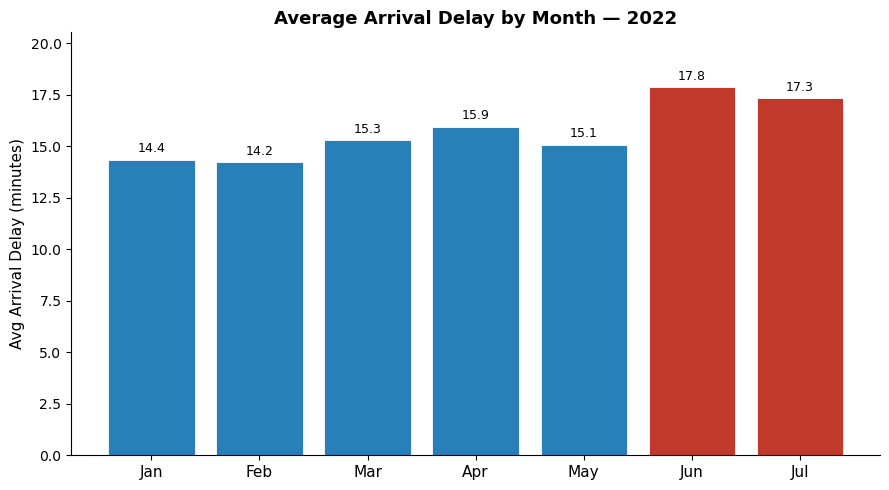

Saved: delay_by_month.png


In [58]:
# ── Chart 1: Average Arrival Delay by Month ─────────────────────────────────
monthly = df_feat.groupBy("Month") \
    .agg(avg("ArrDelayMinutes").alias("Avg_Delay")) \
    .orderBy("Month")

monthly_pd = spark_to_pandas(monthly, sort_col="Month")
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    monthly_pd["Month"],
    monthly_pd["Avg_Delay"],
    color=["#c0392b" if v > 16 else "#2980b9" for v in monthly_pd["Avg_Delay"]],
    edgecolor="white", linewidth=0.6
)
ax.set_xticks(monthly_pd["Month"])
ax.set_xticklabels(month_labels[:len(monthly_pd)], fontsize=11)
ax.set_ylabel("Avg Arrival Delay (minutes)", fontsize=11)
ax.set_title("Average Arrival Delay by Month — 2022", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, monthly_pd["Avg_Delay"].max() * 1.15)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/delay_by_month.png", dpi=150)
plt.show()
print("Saved: delay_by_month.png")

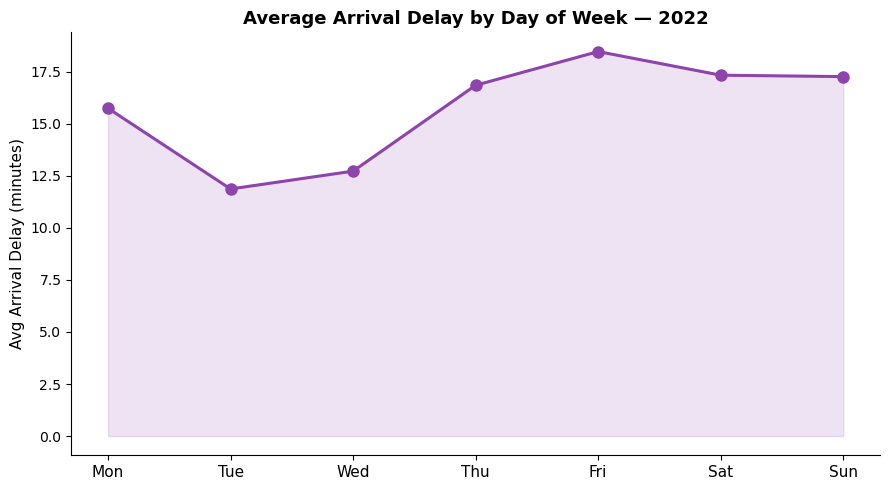

Saved: delay_by_dow.png


In [59]:
# ── Chart 2: Average Arrival Delay by Day of Week ───────────────────────────
dow_pd = spark_to_pandas(
    df_feat.groupBy("DayOfWeek")
           .agg(avg("ArrDelayMinutes").alias("Avg_Delay")),
    sort_col="DayOfWeek"
)
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dow_pd["DayOfWeek"], dow_pd["Avg_Delay"],
        marker="o", color="#8e44ad", linewidth=2.2, markersize=8)
ax.fill_between(dow_pd["DayOfWeek"], dow_pd["Avg_Delay"], alpha=0.15, color="#8e44ad")
ax.set_xticks(dow_pd["DayOfWeek"])
ax.set_xticklabels(dow_labels, fontsize=11)
ax.set_ylabel("Avg Arrival Delay (minutes)", fontsize=11)
ax.set_title("Average Arrival Delay by Day of Week — 2022", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/delay_by_dow.png", dpi=150)
plt.show()
print("Saved: delay_by_dow.png")

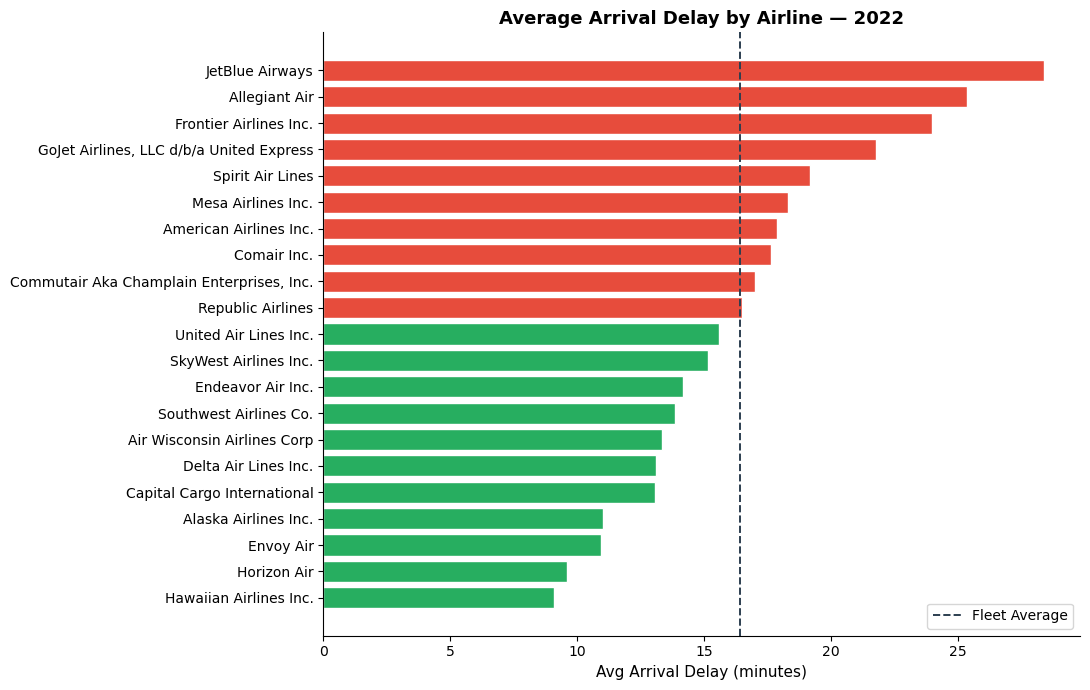

Saved: delay_by_airline.png


In [61]:
# ── Chart 3: Avg Delay by Airline (horizontal bar) ──────────────────────────
airline_pd = spark_to_pandas(
    df_feat.groupBy("Airline")
           .agg(
               avg("ArrDelayMinutes").alias("Avg_Delay"),
               count("*").alias("Num_Flights")
           )
           .filter(col("Num_Flights") >= 5000),
    sort_col="Avg_Delay",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#e74c3c" if v > airline_pd["Avg_Delay"].mean() else "#27ae60"
          for v in airline_pd["Avg_Delay"]]
ax.barh(airline_pd["Airline"], airline_pd["Avg_Delay"], color=colors, edgecolor="white")
ax.axvline(airline_pd["Avg_Delay"].mean(), color="#2c3e50", linestyle="--",
           linewidth=1.4, label="Fleet Average")
ax.set_xlabel("Avg Arrival Delay (minutes)", fontsize=11)
ax.set_title("Average Arrival Delay by Airline — 2022", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/delay_by_airline.png", dpi=150)
plt.show()
print("Saved: delay_by_airline.png")

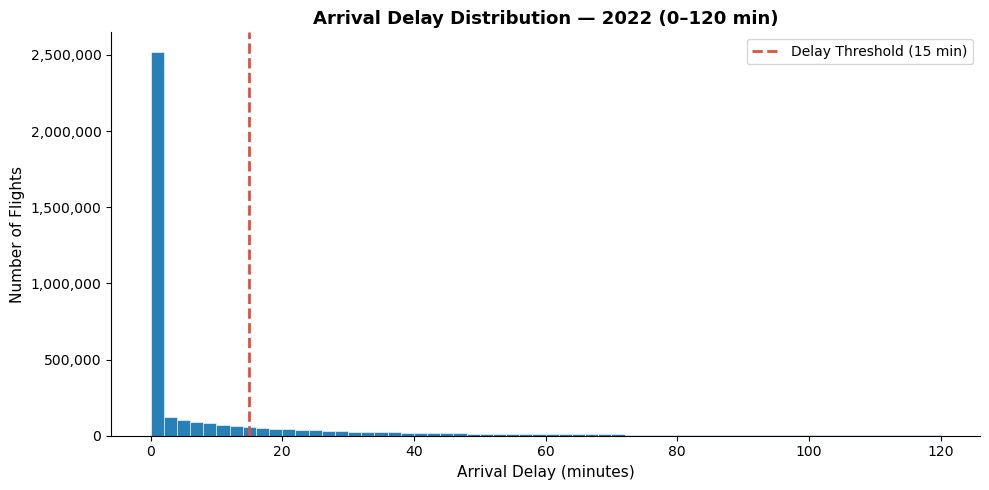

Saved: arrival_delay_distribution.png


In [63]:
# ── Chart 4: Arrival Delay Distribution (0–120 min) ─────────────────────────
# Collect binned delay counts
delay_dist = df_feat.filter(
    (col("ArrDelayMinutes") >= 0) & (col("ArrDelayMinutes") <= 120)
).select("ArrDelayMinutes").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delay_dist["ArrDelayMinutes"], bins=60, color="#2980b9",
        edgecolor="white", linewidth=0.4)
ax.axvline(15, color="#e74c3c", linewidth=2, linestyle="--", label="Delay Threshold (15 min)")
ax.set_xlabel("Arrival Delay (minutes)", fontsize=11)
ax.set_ylabel("Number of Flights", fontsize=11)
ax.set_title("Arrival Delay Distribution — 2022 (0–120 min)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/arrival_delay_distribution.png", dpi=150)
plt.show()
print("Saved: arrival_delay_distribution.png")

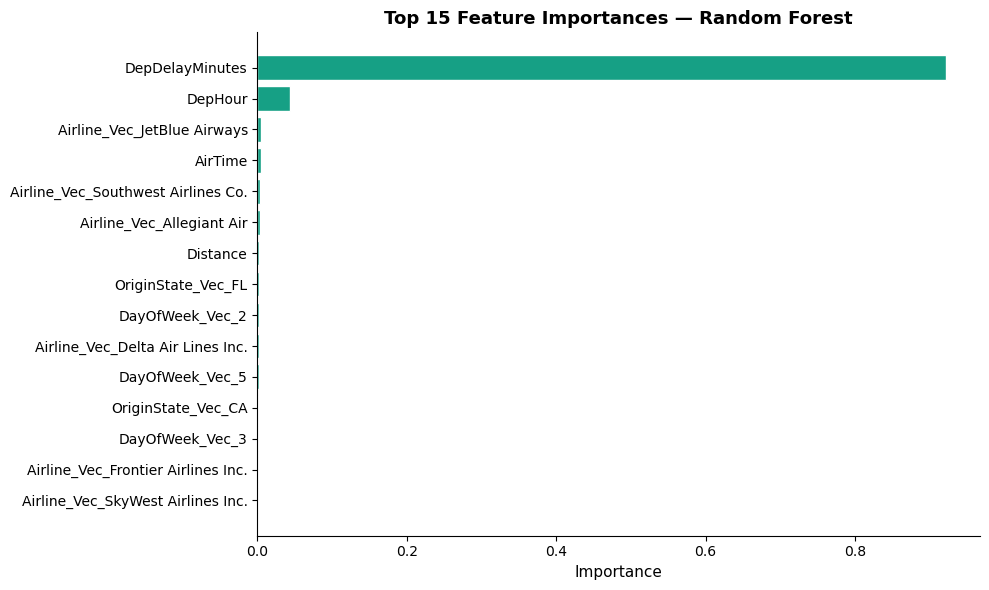

Saved: feature_importance_rf.png


In [64]:
# ── Chart 5: Feature Importance — Random Forest ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fi_plot = fi_rf.sort_values("Importance", ascending=True).tail(15)
ax.barh(fi_plot["Feature"], fi_plot["Importance"], color="#16a085", edgecolor="white")
ax.set_xlabel("Importance", fontsize=11)
ax.set_title("Top 15 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/feature_importance_rf.png", dpi=150)
plt.show()
print("Saved: feature_importance_rf.png")

## 11. Unsupervised Learning — K-Means Clustering

We cluster flights using numeric delay-related features to discover
natural delay-severity groups without using the `IsDelayed` label.

**Features used:** `DepDelayMinutes`, `ArrDelayMinutes`, `AirTime`, `Distance`, `DepHour`

After fitting we reduce to 2-D with PCA for a scatter-plot visualisation,
and use the Silhouette score to pick the best *k* from {2, 3, 4, 5}.


In [68]:
# ── K-Means: Elbow / Silhouette sweep ───────────────────────────────────────
km_feature_cols = ["DepDelayMinutes", "ArrDelayMinutes",
                   "AirTime", "Distance", "DepHour"]

km_assembler = VectorAssembler(
    inputCols=km_feature_cols, outputCol="km_raw", handleInvalid="skip"
)
km_scaler = StandardScaler(
    inputCol="km_raw", outputCol="km_features",
    withStd=True, withMean=True          # mean-centering is fine for dense numeric vectors
)

# Use the full feature-engineered dataset (no label needed)
km_pipeline_pre = Pipeline(stages=[km_assembler, km_scaler])
km_prepared     = km_pipeline_pre.fit(df_feat).transform(df_feat)

sil_evaluator = ClusteringEvaluator(
    featuresCol="km_features", predictionCol="cluster",
    metricName="silhouette", distanceMeasure="squaredEuclidean"
)

k_values   = [2, 3, 4, 5]
sil_scores = []

for k in k_values:
    km = KMeans(featuresCol="km_features", predictionCol="cluster",
                k=k, seed=42, maxIter=30)
    km_model    = km.fit(km_prepared)
    km_preds    = km_model.transform(km_prepared)
    sil         = sil_evaluator.evaluate(km_preds)
    sil_scores.append(sil)
    print(f"k={k}  Silhouette={sil:.4f}  WSSSE={km_model.summary.trainingCost:.2f}")

best_k = k_values[sil_scores.index(max(sil_scores))]
print(f"\nBest k = {best_k}  (highest silhouette = {max(sil_scores):.4f})")


k=2  Silhouette=0.4402  WSSSE=15706728.23
k=3  Silhouette=0.4712  WSSSE=14459542.73
k=4  Silhouette=0.3935  WSSSE=11319852.90
k=5  Silhouette=0.4189  WSSSE=11199690.15

Best k = 3  (highest silhouette = 0.4712)


In [70]:
# ── Fit final K-Means with best_k ───────────────────────────────────────────
km_final      = KMeans(featuresCol="km_features", predictionCol="cluster",
                       k=best_k, seed=42, maxIter=50)
km_model_final = km_final.fit(km_prepared)
km_result      = km_model_final.transform(km_prepared)

# Cluster summary — avg delay per cluster
print("=== Cluster Profiles ===")
km_result.groupBy("cluster") \
    .agg(
        count("*").alias("Num_Flights"),
        spark_round(avg("DepDelayMinutes"), 2).alias("Avg_DepDelay"),
        spark_round(avg("ArrDelayMinutes"), 2).alias("Avg_ArrDelay"),
        spark_round(avg("Distance"),        2).alias("Avg_Distance"),
    ) \
    .orderBy("cluster") \
    .show()

=== Cluster Profiles ===
+-------+-----------+------------+------------+------------+
|cluster|Num_Flights|Avg_DepDelay|Avg_ArrDelay|Avg_Distance|
+-------+-----------+------------+------------+------------+
|      0|    1372445|       19.51|       19.43|     1428.85|
|      1|    2567212|       12.18|       11.98|      462.01|
|      2|       5259|      921.35|      918.12|      849.46|
+-------+-----------+------------+------------+------------+



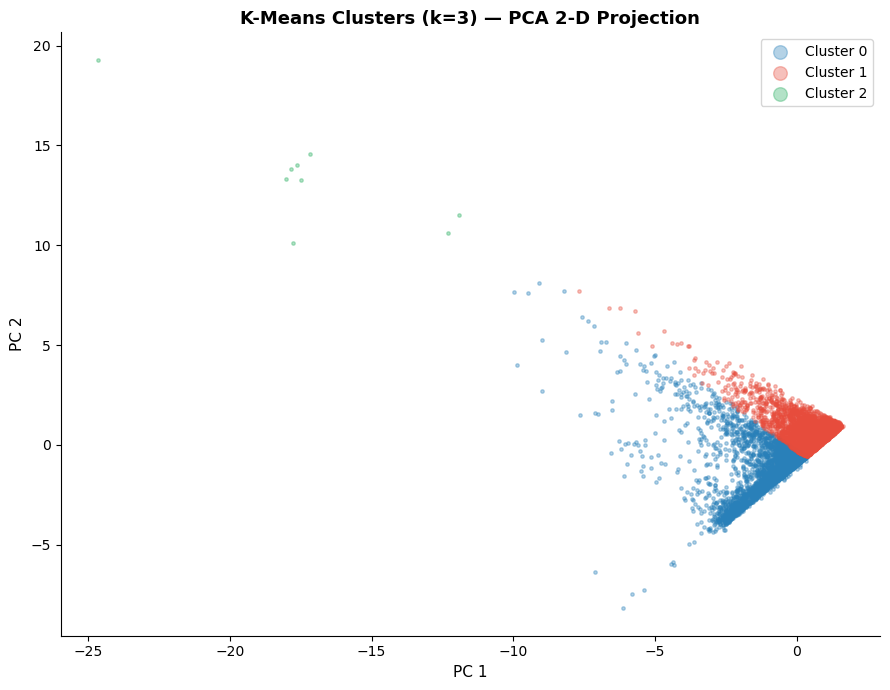

Saved: kmeans_clusters_pca.png


In [72]:
# ── PCA 2-D visualisation of clusters ───────────────────────────────────────
pca_model = PCA(k=2, inputCol="km_features", outputCol="pca_coords") \
                .fit(km_prepared)
km_pca = pca_model.transform(km_result) \
           .select("pca_coords", "cluster") \
           .limit(10_000)          # sample for plotting speed

km_pdf = km_pca.toPandas()
km_pdf["pc1"] = km_pdf["pca_coords"].apply(lambda v: float(v[0]))
km_pdf["pc2"] = km_pdf["pca_coords"].apply(lambda v: float(v[1]))

palette = ["#2980b9", "#e74c3c", "#27ae60", "#f39c12", "#8e44ad"]
fig, ax = plt.subplots(figsize=(9, 7))
for c in sorted(km_pdf["cluster"].unique()):
    sub = km_pdf[km_pdf["cluster"] == c]
    ax.scatter(sub["pc1"], sub["pc2"],
               s=6, alpha=0.35, color=palette[c], label=f"Cluster {c}")
ax.set_xlabel("PC 1", fontsize=11)
ax.set_ylabel("PC 2", fontsize=11)
ax.set_title(f"K-Means Clusters (k={best_k}) — PCA 2-D Projection", fontsize=13, fontweight="bold")
ax.legend(markerscale=4, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/kmeans_clusters_pca.png", dpi=150)
plt.show()
print("Saved: kmeans_clusters_pca.png")


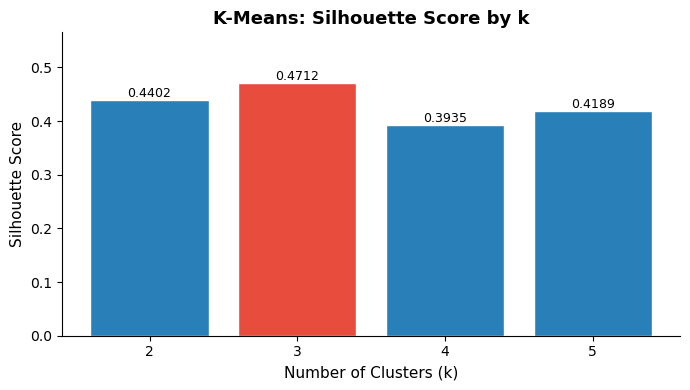

Saved: kmeans_silhouette.png


In [73]:
# ── Silhouette score chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#e74c3c" if k == best_k else "#2980b9" for k in k_values]
ax.bar([str(k) for k in k_values], sil_scores, color=bar_colors, edgecolor="white")
ax.set_xlabel("Number of Clusters (k)", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title("K-Means: Silhouette Score by k", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(sil_scores) * 1.2)
for i, v in enumerate(sil_scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/kmeans_silhouette.png", dpi=150)
plt.show()
print("Saved: kmeans_silhouette.png")


## 12. Neural Network — PyTorch Binary Classifier

We export a 5 % random sample from the Spark DataFrames to Pandas,
then train a fully-connected feed-forward network in PyTorch.

**Architecture:** `Input → 128 → 64 → 32 → 1 (sigmoid)`
**Loss:** BCELoss  |  **Optimizer:** Adam  |  **Epochs:** 20  |  **Batch size:** 512


In [77]:
# ── Collect a sample to Pandas (Spark → PyTorch bridge) ─────────────────────
SAMPLE_FRAC = 0.05      # 5 % keeps training fast in a notebook environment

nn_num_cols = ["DepDelayMinutes", "Distance", "AirTime", "DepHour", "isWeekend"]

train_pd = train_df.select(nn_num_cols + ["IsDelayed"]) \
                   .sample(fraction=SAMPLE_FRAC, seed=42) \
                   .toPandas()
test_pd  = test_df.select(nn_num_cols + ["IsDelayed"]) \
                  .sample(fraction=SAMPLE_FRAC, seed=42) \
                  .toPandas()

# Drop any remaining NaNs in the sampled subset
train_pd = train_pd.dropna()
test_pd  = test_pd.dropna()

X_train_raw = train_pd[nn_num_cols].values.astype(np.float32)
y_train     = train_pd["IsDelayed"].values.astype(np.float32)
X_test_raw  = test_pd[nn_num_cols].values.astype(np.float32)
y_test      = test_pd["IsDelayed"].values.astype(np.float32)

# Scale features with sklearn (fit on train only)
sk_scaler   = SkScaler()
X_train     = sk_scaler.fit_transform(X_train_raw)
X_test      = sk_scaler.transform(X_test_raw)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=512, shuffle=True
)

print(f"NN train samples : {len(X_train_t):,}")
print(f"NN test  samples : {len(X_test_t):,}")
print(f"Input features   : {X_train.shape[1]}")


NN train samples : 157,378
NN test  samples : 39,445
Input features   : 5


In [79]:
# ── Define the Network ───────────────────────────────────────────────────────
class FlightDelayNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nn_model  = FlightDelayNet(in_features=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print(nn_model)
print(f"\nTraining on: {device}")


FlightDelayNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Training on: cpu


In [81]:
# ── Training loop ────────────────────────────────────────────────────────────
EPOCHS      = 20
train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    nn_model.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = nn_model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(Xb)
    train_losses.append(epoch_loss / len(X_train_t))

    # ---- validation ----
    nn_model.eval()
    with torch.no_grad():
        val_pred = nn_model(X_test_t.to(device))
        val_loss = criterion(val_pred, y_test_t.to(device)).item()
    val_losses.append(val_loss)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  train_loss={train_losses[-1]:.4f}  val_loss={val_loss:.4f}")

print("\nNeural Network training complete.")


Epoch   1/20  train_loss=0.2500  val_loss=0.2063
Epoch   5/20  train_loss=0.1986  val_loss=0.1876
Epoch  10/20  train_loss=0.1957  val_loss=0.1868
Epoch  15/20  train_loss=0.1941  val_loss=0.1866
Epoch  20/20  train_loss=0.1936  val_loss=0.1862

Neural Network training complete.


In [83]:
# ── Evaluate ─────────────────────────────────────────────────────────────────
nn_model.eval()
with torch.no_grad():
    nn_probs = nn_model(X_test_t.to(device)).cpu().numpy().flatten()

nn_preds = (nn_probs >= 0.5).astype(int)

nn_acc  = accuracy_score(y_test, nn_preds)
nn_auc  = roc_auc_score(y_test, nn_probs)
nn_f1   = f1_score(y_test, nn_preds, average="weighted")

print("=== Neural Network Test Metrics ===")
print(f"  Accuracy  : {nn_acc:.4f}")
print(f"  AUC-ROC   : {nn_auc:.4f}")
print(f"  F1 (wtd.) : {nn_f1:.4f}")


=== Neural Network Test Metrics ===
  Accuracy  : 0.9358
  AUC-ROC   : 0.9465
  F1 (wtd.) : 0.9334


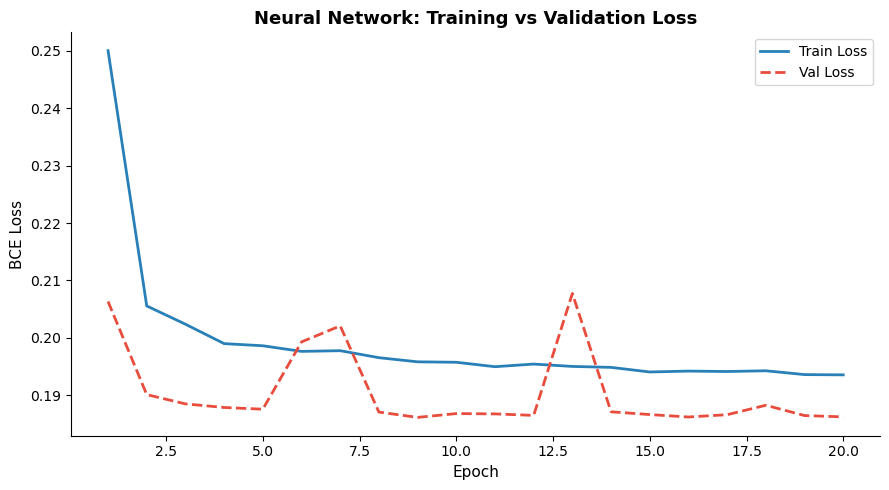

Saved: nn_loss_curve.png


In [85]:
# ── Training / Validation Loss Curve ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss", color="#2980b9",  linewidth=2)
ax.plot(range(1, EPOCHS + 1), val_losses,   label="Val Loss",   color="#e74c3c", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("BCE Loss", fontsize=11)
ax.set_title("Neural Network: Training vs Validation Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/nn_loss_curve.png", dpi=150)
plt.show()
print("Saved: nn_loss_curve.png")


## 13. Final Model Comparison

In [87]:
auc_eval  = BinaryClassificationEvaluator(labelCol="IsDelayed", metricName="areaUnderROC")
acc_eval  = MulticlassClassificationEvaluator(labelCol="IsDelayed", metricName="accuracy")
f1_eval   = MulticlassClassificationEvaluator(labelCol="IsDelayed", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="IsDelayed", metricName="weightedPrecision")
rec_eval  = MulticlassClassificationEvaluator(labelCol="IsDelayed", metricName="weightedRecall")

def evaluate_model(preds, name):
    return {
        "Model"    : name,
        "Accuracy" : round(acc_eval.evaluate(preds),  4),
        "AUC-ROC"  : round(auc_eval.evaluate(preds),  4),
        "F1"       : round(f1_eval.evaluate(preds),   4),
        "Precision": round(prec_eval.evaluate(preds), 4),
        "Recall"   : round(rec_eval.evaluate(preds),  4),
    }

results = [
    evaluate_model(preds_lr,  "Logistic Regression"),
    evaluate_model(preds_rf,  "Random Forest"),
    evaluate_model(preds_gbt, "GBT"),
    # Neural Network — evaluated separately (PyTorch, not Spark)
    {
        "Model"    : "Neural Network (PyTorch)",
        "Accuracy" : round(float(nn_acc),  4),
        "AUC-ROC"  : round(float(nn_auc),  4),
        "F1"       : round(float(nn_f1),   4),
        "Precision": None,   # sklearn weighted precision omitted for brevity
        "Recall"   : None,
    },
]

results_df = pd.DataFrame(results).set_index("Model")
print("\n=== Final Model Comparison ===")
print(results_df.to_string())



=== Final Model Comparison ===
                          Accuracy  AUC-ROC      F1  Precision  Recall
Model                                                                 
Logistic Regression         0.9346   0.9457  0.9325     0.9336  0.9346
Random Forest               0.9293   0.9090  0.9264     0.9285  0.9293
GBT                         0.9334   0.9436  0.9309     0.9325  0.9334
Neural Network (PyTorch)    0.9358   0.9465  0.9334        NaN     NaN


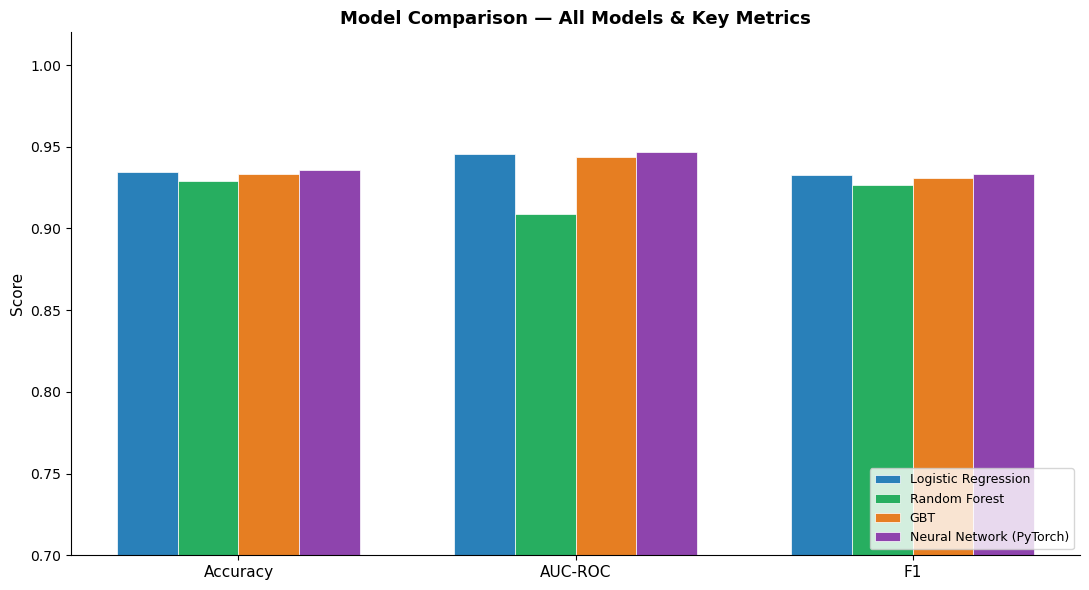

Saved: model_comparison.png


In [88]:
# ── Chart 6: Model Comparison Bar Chart ─────────────────────────────────────
metrics   = ["Accuracy", "AUC-ROC", "F1"]
x         = range(len(metrics))
width     = 0.18
colors_m  = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]

fig, ax = plt.subplots(figsize=(11, 6))
for i, (row, color) in enumerate(zip(results, colors_m)):
    offsets = [xi + (i - 1.5) * width for xi in x]
    vals    = [row[m] for m in metrics]
    ax.bar(offsets, vals, width=width, label=row["Model"],
           color=color, edgecolor="white", linewidth=0.5)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.70, 1.02)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — All Models & Key Metrics", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")


In [89]:
# Free cached data and shut down Spark
train_df.unpersist()
test_df.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
